In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [42]:
df = pd.read_csv("student+performance/student/student-por.csv", sep = ";")

In [43]:
print(df.head())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5        0  11  13  13  

[5 rows x 33 columns]


In [44]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [45]:
print(df.describe())

              age        Medu        Fedu  traveltime   studytime    failures  \
count  649.000000  649.000000  649.000000  649.000000  649.000000  649.000000   
mean    16.744222    2.514638    2.306626    1.568567    1.930663    0.221880   
std      1.218138    1.134552    1.099931    0.748660    0.829510    0.593235   
min     15.000000    0.000000    0.000000    1.000000    1.000000    0.000000   
25%     16.000000    2.000000    1.000000    1.000000    1.000000    0.000000   
50%     17.000000    2.000000    2.000000    1.000000    2.000000    0.000000   
75%     18.000000    4.000000    3.000000    2.000000    2.000000    0.000000   
max     22.000000    4.000000    4.000000    4.000000    4.000000    3.000000   

           famrel    freetime       goout        Dalc        Walc      health  \
count  649.000000  649.000000  649.000000  649.000000  649.000000  649.000000   
mean     3.930663    3.180277    3.184900    1.502311    2.280431    3.536210   
std      0.955717    1.0510

In [46]:
print(df.shape)

(649, 33)


In [47]:
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


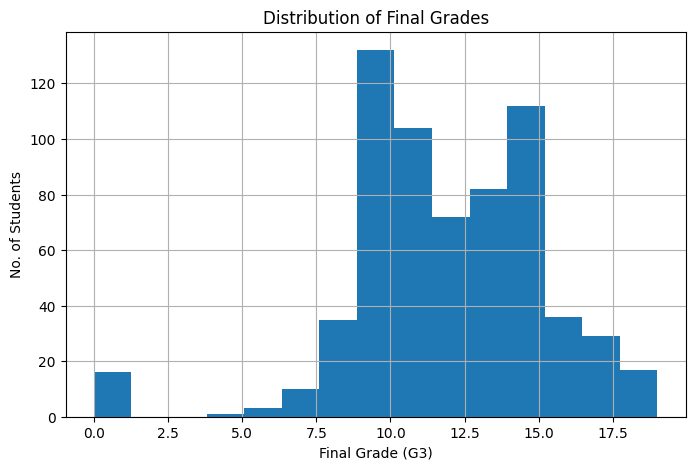

In [48]:
plt.figure(figsize=(8,5))
plt.hist(df["G3"], bins = 15)
plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("No. of Students")
plt.grid(True)
plt.show()

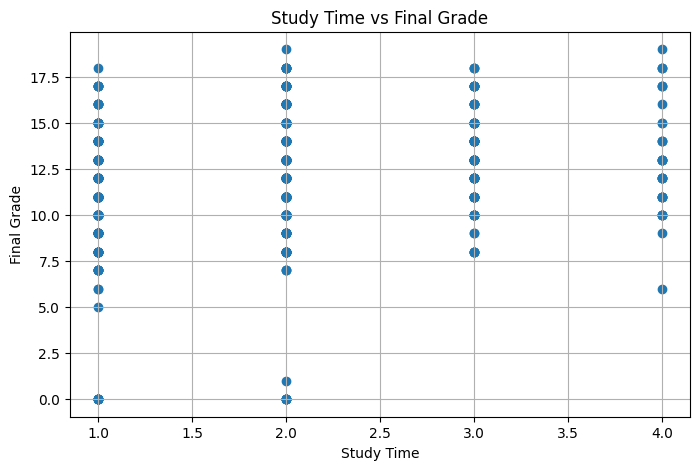

In [49]:
plt.figure(figsize=(8,5))
plt.scatter(df["studytime"], df["G3"])
plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time")
plt.ylabel("Final Grade")
plt.grid(True)
plt.show()

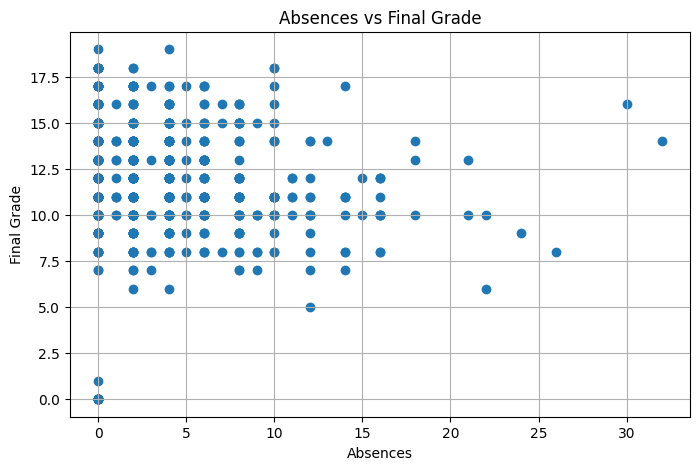

In [50]:
plt.figure(figsize=(8,5))
plt.scatter(df["absences"], df["G3"])
plt.title("Absences vs Final Grade")
plt.xlabel("Absences")
plt.ylabel("Final Grade")
plt.grid(True)
plt.show()

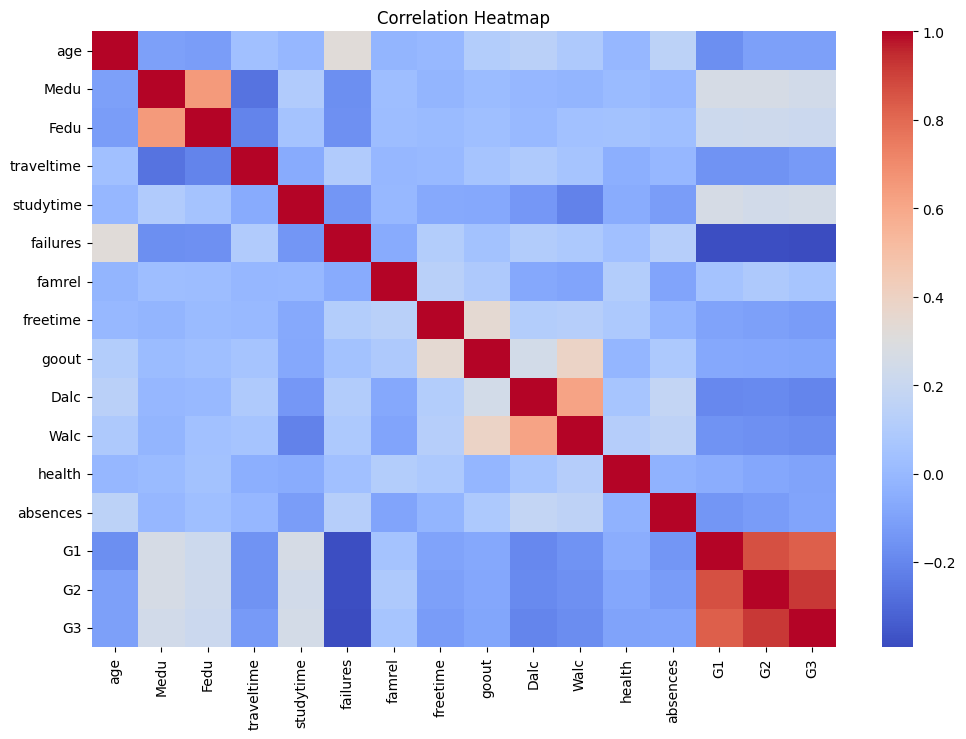

In [51]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

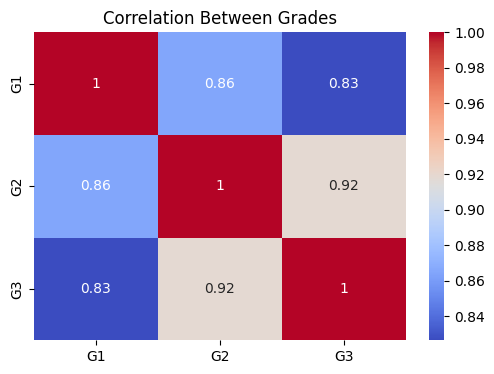

In [52]:
plt.figure(figsize=(6,4))
sns.heatmap(df[["G1","G2","G3"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Grades")
plt.show()

In [53]:
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

print(df.head())

   school  sex  age  address  famsize  Pstatus  Medu  Fedu  Mjob  Fjob  ...  \
0       0    0   18        1        0        0     4     4     0     4  ...   
1       0    0   17        1        0        1     1     1     0     2  ...   
2       0    0   15        1        1        1     1     1     0     2  ...   
3       0    0   15        1        0        1     4     2     1     3  ...   
4       0    0   16        1        0        1     3     3     2     2  ...   

   famrel  freetime  goout  Dalc  Walc  health  absences  G1  G2  G3  
0       4         3      4     1     1       3         4   0  11  11  
1       5         3      3     1     1       3         2   9  11  11  
2       4         3      2     2     3       3         6  12  13  12  
3       3         2      2     1     1       5         0  14  14  14  
4       4         3      2     1     2       5         0  11  13  13  

[5 rows x 33 columns]


TEST CASE 1 - USING ALL THE FEATURES GIVEN

In [54]:
X = df.drop("G3", axis=1)
Y = df["G3"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=50)

MODEL 1 - LINEAR REGRESSION

In [55]:
lr = LinearRegression()
lr.fit(X_train, Y_train)
Y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(Y_test, Y_pred_lr))
r2_lr = r2_score(Y_test, Y_pred_lr)
print("RMSE :", rmse_lr)
print("R2 :", r2_lr)

RMSE : 1.3109521356606666
R2 : 0.8078117044037603


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


MODEL 2 - DECISION TREE REGRESSOR

In [56]:
dt = DecisionTreeRegressor(random_state=50)
dt.fit(X_train, Y_train)
Y_pred_dt = dt.predict(X_test)

rmse_dt = np.sqrt(mean_squared_error(Y_test, Y_pred_dt))
r2_dt = r2_score(Y_test, Y_pred_dt)
print("RMSE :", rmse_dt)
print("R2 :", r2_dt)

RMSE : 1.8563819235690284
R2 : 0.6146211058468543


MODEL 3 - RANDOM FOREST REGRESSOR

In [57]:
rf = RandomForestRegressor(n_estimators=100, random_state=50)
rf.fit(X_train, Y_train)
Y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(Y_test, Y_pred_rf))
r2_rf = r2_score(Y_test, Y_pred_rf)
print("RMSE :", rmse_rf)
print("R2 :", r2_rf)

RMSE : 1.3450330279044622
R2 : 0.7976891559249358


In [58]:
results1 = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "RMSE":[
        rmse_lr,
        rmse_dt,
        rmse_rf
    ],

    "R2":[
        r2_lr,
        r2_dt,
        r2_rf
    ]
})

print(results1)

               Model      RMSE        R2
0  Linear Regression  1.310952  0.807812
1      Decision Tree  1.856382  0.614621
2      Random Forest  1.345033  0.797689


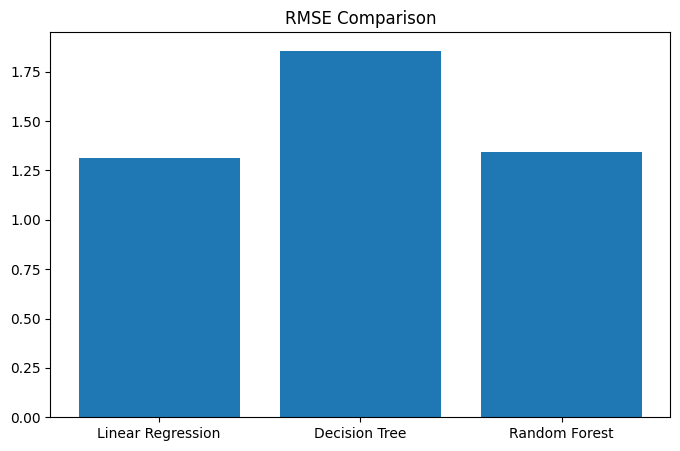

In [59]:
plt.figure(figsize=(8,5))
plt.bar(results1["Model"], results1["RMSE"])
plt.title("RMSE Comparison")
plt.show()

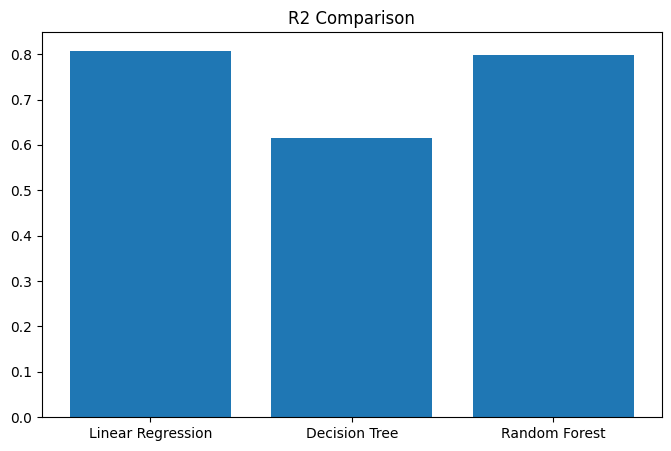

In [60]:
plt.figure(figsize=(8,5))
plt.bar(results1["Model"], results1["R2"])
plt.title("R2 Comparison")
plt.show()

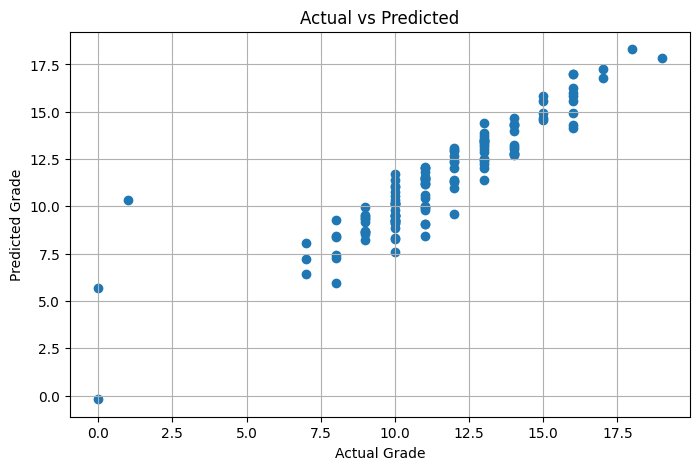

In [61]:
plt.figure(figsize=(8,5))
plt.scatter(Y_test, Y_pred_lr)
plt.xlabel("Actual Grade")
plt.ylabel("Predicted Grade")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

In [62]:
importance = rf.feature_importances_

for col, imp in zip(df.drop("G3", axis=1).columns, importance):
    print(col, ":", round(imp,3))

school : 0.002
sex : 0.002
age : 0.008
address : 0.001
famsize : 0.005
Pstatus : 0.001
Medu : 0.005
Fedu : 0.004
Mjob : 0.005
Fjob : 0.003
reason : 0.006
guardian : 0.002
traveltime : 0.004
studytime : 0.002
failures : 0.005
schoolsup : 0.003
famsup : 0.003
paid : 0.001
activities : 0.002
nursery : 0.003
higher : 0.001
internet : 0.001
romantic : 0.003
famrel : 0.01
freetime : 0.005
goout : 0.005
Dalc : 0.004
Walc : 0.007
health : 0.009
absences : 0.043
G1 : 0.013
G2 : 0.834


In [63]:
feature_df = pd.DataFrame({
    "Feature":
    df.drop("G3", axis=1).columns,
    
    "Importance":
    importance
})

feature_df = feature_df.sort_values(by="Importance", ascending=False)
print(feature_df.head(10))

     Feature  Importance
31        G2    0.833888
29  absences    0.042595
30        G1    0.012996
23    famrel    0.009632
28    health    0.009181
2        age    0.008422
27      Walc    0.006565
10    reason    0.005738
8       Mjob    0.005432
6       Medu    0.005371


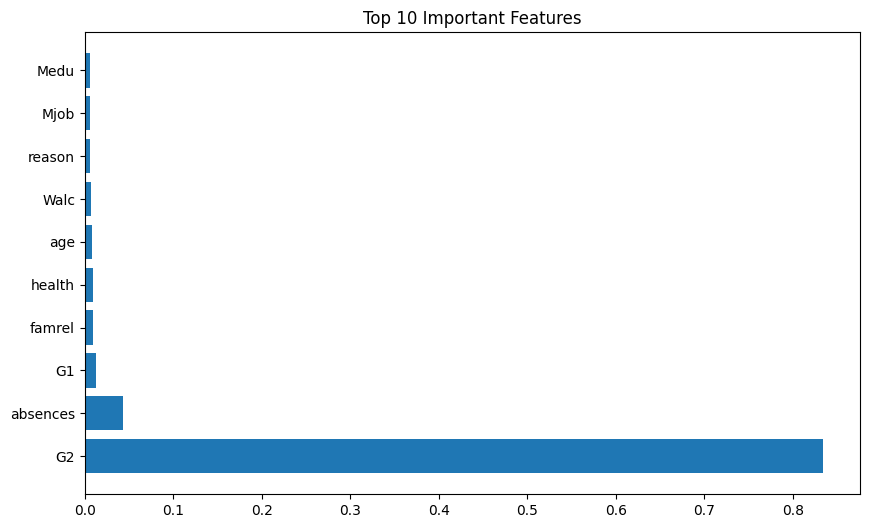

In [64]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_df["Feature"][:10],
    feature_df["Importance"][:10]
)

plt.title("Top 10 Important Features")
plt.show()

In [65]:
scores = cross_val_score(
    rf,
    X,
    Y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores")
print(scores)
print("Average R2")
print(scores.mean())

Cross Validation Scores
[0.74396095 0.69117528 0.82123849 0.84613021 0.79095833]
Average R2
0.7786926512095584


TEST CASE 2 - REMOVING FEATURES G1 AND G2

In [66]:
df2 = df.copy()
X = df2.drop(["G1","G2","G3"], axis=1)
Y = df2["G3"]

In [67]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

MODEL 1 - LINEAR REGRESSION

In [68]:
lr = LinearRegression()
lr.fit(X_train, Y_train)
Y_pred_lr = lr.predict(X_test)

rmse_lr2 = np.sqrt(mean_squared_error(Y_test, Y_pred_lr))
r2_lr2 = r2_score(Y_test, Y_pred_lr)
print("RMSE :", rmse_lr2)
print("R2 :", r2_lr2)

RMSE : 2.8417957681628856
R2 : 0.1718582444823583


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


MODEL 2 - DECISION TREE REGRESSOR

In [69]:
dt = DecisionTreeRegressor(random_state=50)
dt.fit(X_train, Y_train)
Y_pred_dt = dt.predict(X_test)

rmse_dt2 = np.sqrt(mean_squared_error(Y_test, Y_pred_dt))
r2_dt2 = r2_score(Y_test, Y_pred_dt)
print("RMSE :", rmse_dt2)
print("R2 :", r2_dt2)

RMSE : 3.7220755169456403
R2 : -0.42065726560034955


MODEL 3 - RANDOM FOREST REGRESSOR

In [70]:
rf = RandomForestRegressor(n_estimators=100, random_state=50)
rf.fit(X_train, Y_train)
Y_pred_rf = rf.predict(X_test)

rmse_rf2 = np.sqrt(mean_squared_error(Y_test, Y_pred_rf))
r2_rf2 = r2_score(Y_test, Y_pred_rf)
print("RMSE :", rmse_rf2)
print("R2 :", r2_rf2)

RMSE : 2.8024330088747473
R2 : 0.1946411494866629


In [71]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "R2 With G1 G2":[
        r2_lr,
        r2_dt,
        r2_rf
    ],

    "R2 Without G1 G2":[
        r2_lr2,
        r2_dt2,
        r2_rf2
    ]
})

print(comparison)

               Model  R2 With G1 G2  R2 Without G1 G2
0  Linear Regression       0.807812          0.171858
1      Decision Tree       0.614621         -0.420657
2      Random Forest       0.797689          0.194641
